# 6.6.1 从批量最小二乘到递推更新

## 学习目标与先修知识

能从带初始正则项的最小二乘目标推导正规方程和秩一更新（rank-one update），说明递推最小二乘（recursive least squares，RLS）怎样逐条利用观测（observation）；能用批量解独立核对，并区分逆信息矩阵（inverse information matrix）与参数（parameter）协方差（covariance）。

先修：[最小二乘与误差假设](../04-最小二乘与参数估计/01-最小二乘与误差假设.ipynb)、[激励与可辨识范围](../05-动态辨识、实验设计与验证/02-激励与可辨识范围.ipynb)。复习向量（vector）外积、矩阵乘法（matrix multiplication）、正定（positive definite）二次型。

## 具体问题

培养室每隔一段时间给出一次物质净变化读数。若每到一条记录都重读全部旧数据并重新拟合，模型（model）会越来越慢。能否只保留当前参数与一个小矩阵（matrix），又与同一个批量目标完全一致？

先考虑标量 y=θ+ε。初始猜测 θ₀=0，初始约束强度为1，先后读到2和4。第一步并不是直接相信2：最小化 θ²+(2−θ)² 得1；第二步最小化 θ²+(2−θ)²+(4−θ)² 得2。下一条预测只能用上一条完成后的参数。

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
from systems_science import plot_style, show_table
plot_style()
BLUE, PINK, GREEN, GRAY = '#008bfb', '#ff0051', '#009e73', '#555555'


## 初步实验

In [2]:
values = [2., 4.]
prefix_estimates = [sum(values[:n]) / (1 + n) for n in range(1, 3)]
display(Markdown(show_table(['已到达条数', '更新前预测', '更新后参数'],
                           [(1, 0., prefix_estimates[0]), (2, prefix_estimates[0], prefix_estimates[1])])))

| 已到达条数 | 更新前预测 | 更新后参数 |
| --- | --- | --- |
| 1 | 0 | 1 |
| 2 | 1 | 2 |

## 模型假设

本节回归为 $y_i=\phi_i^\mathsf{T}\theta+\epsilon_i$。用固定参照量缩放净变化、所追踪物质总量（tracked amount）和输入（input）后，$y,\phi,\theta$ 都无量纲（dimensionless）；例如清除近似 $\Delta A/h=g u-kA+\epsilon$ 可用 $\phi=(u,-A)$、$\theta=(g,k)$ 的缩放版本表达。这里每次读数之前的回归量被视为已知且无误差。真实含噪浓度（concentration）差分可能与回归量相关，不能直接照搬本节统计结论。

代数更新本身不要求误差服从高斯分布（Gaussian distribution）。讨论抽样协方差时另限定：设计固定、参数不变、误差独立、均值为零、方差（variance）为 $\sigma^2$。初始中心 $\theta_0$ 固定，$H_0$ 对称正定；它是对参数偏离初始中心的惩罚，不是观测证据，也不默认解释为随机先验（prior）。

## 数学解释与推导

### 从批量目标保留两项累计量

第 n 条之后最小化
$$J_n(\theta)=(\theta-\theta_0)^\mathsf{T}H_0(\theta-\theta_0)
+\sum_{i=1}^{n}(y_i-\phi_i^\mathsf{T}\theta)^2.$$
逐项对参数求导并除以2，得到
$$H_n\theta_n=b_n,\qquad H_n=H_0+\sum_{i=1}^n\phi_i\phi_i^\mathsf{T},\qquad
b_n=H_0\theta_0+\sum_{i=1}^n\phi_i y_i.$$
$H_n$ 是这个目标的二分之一 Hessian；这里用“信息矩阵”表示该目标累积的曲率。外积 $\phi\phi^\mathsf{T}$ 每列都是 $\phi$ 的倍数，非零时只有一个独立方向，所以称秩一更新。每条只增加 $H_n=H_{n-1}+\phi_n\phi_n^\mathsf{T}$ 和 $b_n=b_{n-1}+\phi_n y_n$。

### 避免每一步重新求逆

令 $P=H^{-1}$，$v=P\phi$，$s=\phi^\mathsf{T}v$。尝试新逆矩阵（inverse matrix）为 $P-cvv^\mathsf{T}$。直接相乘：
$$ (H+\phi\phi^\mathsf{T})(P-cvv^\mathsf{T})
=I+[1-c(1+s)]\phi v^\mathsf{T}.$$
取 $c=1/(1+s)$ 即为单位矩阵（identity matrix）；正定性（positive definiteness）使分母严格为正。因此
$$K_n=\frac{P_{n-1}\phi_n}{1+\phi_n^\mathsf{T}P_{n-1}\phi_n},\qquad
P_n=P_{n-1}-K_n\phi_n^\mathsf{T}P_{n-1}.$$
把 $b_{n-1}=H_{n-1}\theta_{n-1}$ 代回，可得
$$\widehat y_{n|n-1}=\phi_n^\mathsf{T}\theta_{n-1},\qquad
\theta_n=\theta_{n-1}+K_n(y_n-\widehat y_{n|n-1}).$$
在实数精确计算中，这个递推直接给出同一批量目标的最小点。每条更新需要约 $d^2$ 次运算，保留 d 个参数与 d×d 矩阵；下面保留估计历史，以便与批量结果逐步比较。浮点舍入误差（round-off error）会影响两种计算路径的数值差。

### 逆信息不总是参数协方差

将固定设计（fixed design）写为 Φ，$H=H_0+\Phi^\mathsf{T}\Phi$。随机部分是 $H^{-1}\Phi^\mathsf{T}\epsilon$，因此
$$\operatorname{Cov}(\hat\theta)=\sigma^2H^{-1}\Phi^\mathsf{T}\Phi H^{-1}.$$
偏差为 $H^{-1}H_0(\theta_0-\theta)$。只有无正则、满列秩（rank）的普通最小二乘（ordinary least squares，OLS）等相应条件下，才化简为 $\sigma^2P$。初始正则保证可逆，不代表回归数据充分激励了每个方向。若采用高斯先验，则需重新解释后验（posterior）协方差；它与这里固定初始中心的重复抽样方差不是同一个对象。

## 核心实现

先取 λ=1。为了下一节复用，函数保留 forgetting 这个参数；本节所有主实验都使用1。代码中的 prediction 与 direction 必须在改写参数和 P 之前计算。

In [3]:
def rls_trace(regressors, observed, initial_parameters, initial_inverse, forgetting):
    parameters = initial_parameters.copy()
    inverse = [row.copy() for row in initial_inverse]
    dimension = len(parameters)
    predictions, parameter_history, inverse_history = [], [], []
    for features, target in zip(regressors, observed):
        prediction = sum(x * b for x, b in zip(features, parameters))
        direction = [sum(inverse[i][j] * features[j] for j in range(dimension))
                     for i in range(dimension)]
        denominator = forgetting + sum(x * v for x, v in zip(features, direction))
        gain = [v / denominator for v in direction]
        error = target - prediction
        parameters = [b + g * error for b, g in zip(parameters, gain)]
        inverse = [[(inverse[i][j] - direction[i] * direction[j] / denominator) / forgetting
                    for j in range(dimension)] for i in range(dimension)]
        predictions.append(prediction)
        parameter_history.append(parameters.copy())
        inverse_history.append([row.copy() for row in inverse])
    return predictions, parameter_history, inverse_history


## 对照实验

课程回归量在内存中构造：输入和初始总量覆盖不同方向，独立误差由 NumPy default_rng、种子6601产生，60条记录，标准差（standard deviation）0.03。真实参数仅在生成与最后核对中读取，不传给递推或批量拟合。

In [4]:
rng = np.random.default_rng(6601)
regressors = np.column_stack([rng.uniform(.2, 1.8, 60), -rng.uniform(.1, 2.0, 60)])
reference_parameters = np.array([.7, .25])
observed = regressors @ reference_parameters + rng.normal(0., .03, len(regressors))
initial_parameters = [.1, .1]
initial_inverse = [[2., .2], [.2, 1.]]
predictions, parameter_history, inverse_history = rls_trace(
    regressors.tolist(), observed.tolist(), initial_parameters, initial_inverse, 1.)

In [5]:
def weighted_batch_trace(regressors, observed, initial_parameters, initial_inverse, forgetting):
    # 每个前缀重新构造整个目标函数，不复用递推增益公式。
    features = np.asarray(regressors, dtype=float)
    targets = np.asarray(observed, dtype=float)
    initial = np.asarray(initial_parameters, dtype=float)
    initial_information = np.linalg.inv(np.asarray(initial_inverse, dtype=float))
    parameters, inverses, predictions = [], [], []
    previous = initial.copy()
    for count in range(1, len(targets) + 1):
        predictions.append(float(features[count - 1] @ previous))
        weights = forgetting ** np.arange(count - 1, -1, -1)
        design = features[:count]
        information = forgetting ** count * initial_information + design.T @ (weights[:, None] * design)
        right = forgetting ** count * initial_information @ initial + design.T @ (weights * targets[:count])
        previous = np.linalg.solve(information, right)
        parameters.append(previous.copy())
        inverses.append(np.linalg.solve(information, np.eye(len(initial))))
    return predictions, parameters, inverses


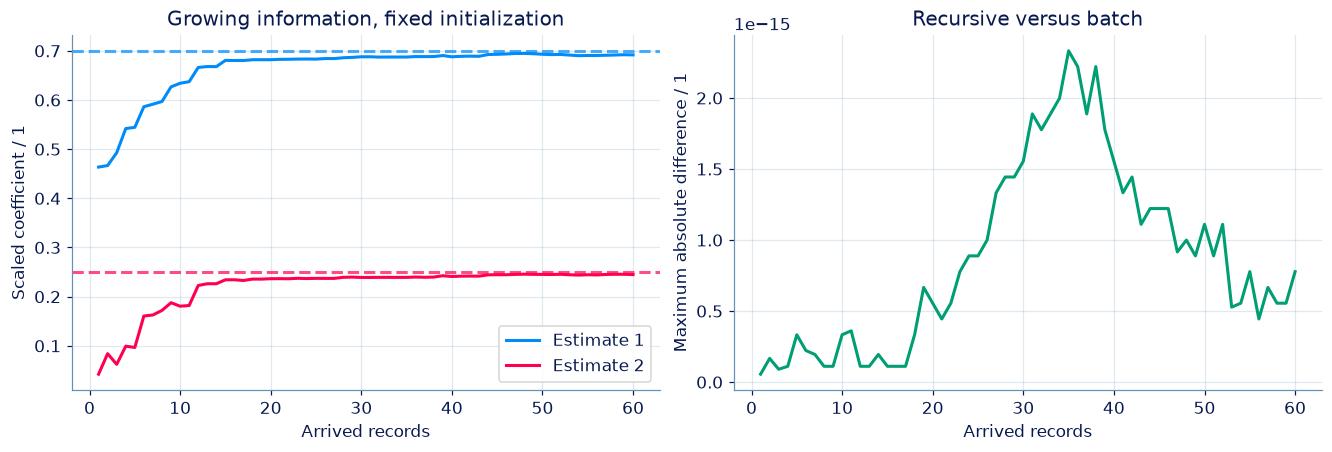

逐前缀参数最大绝对差： 2.3314683517128287e-15
最后估计： [0.69176007 0.24478886]


In [6]:
batch_prediction, batch_parameters, batch_inverses = weighted_batch_trace(
    regressors, observed, initial_parameters, initial_inverse, 1.)
np.testing.assert_allclose(parameter_history, batch_parameters, atol=1e-12)
np.testing.assert_allclose(inverse_history, batch_inverses, atol=1e-12)
np.testing.assert_allclose(predictions, batch_prediction, atol=1e-12)
history = np.array(parameter_history)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for j, color in enumerate([BLUE, PINK]):
    axes[0].plot(range(1, 61), history[:, j], color=color, label=f'Estimate {j+1}')
    axes[0].axhline(reference_parameters[j], color=color, ls='--', alpha=.7)
axes[0].set(xlabel='Arrived records', ylabel='Scaled coefficient / 1', title='Growing information, fixed initialization')
axes[0].legend()
differences = np.max(np.abs(history - batch_parameters), axis=1)
axes[1].plot(range(1, 61), differences, color=GREEN)
axes[1].set(xlabel='Arrived records', ylabel='Maximum absolute difference / 1', title='Recursive versus batch')
plt.show()
print('逐前缀参数最大绝对差：', float(differences.max()))
print('最后估计：', history[-1])

再单独检验协方差，而不是把一条参数轨迹（trajectory）的抖动当方差。固定同一设计和正则中心，使用种子6602的2000组独立误差。这里是课程机制核验，样本方差仍有蒙特卡洛波动。

| 量 | 数值 / 1 |
| --- | --- |
| 2000次抽样方差 | 0.562549 |
| 固定中心正确理论方差 | 0.555556 |
| 直接使用σ²P | 0.666667 |

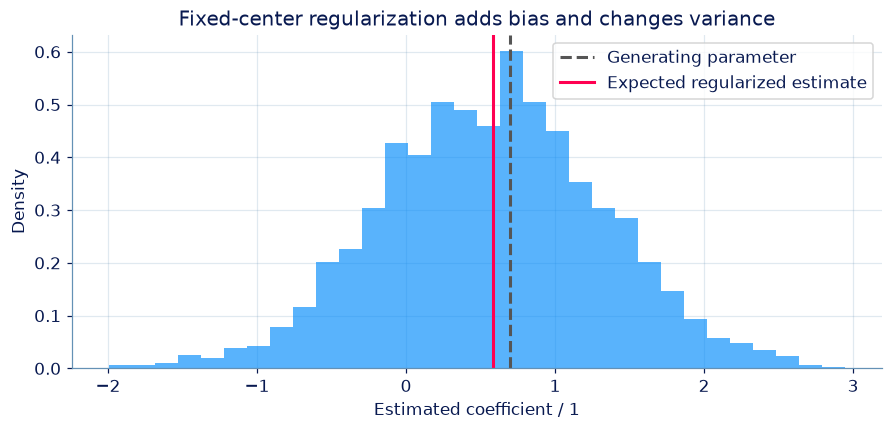

In [7]:
features = np.array([1., 2.])
alpha, sigma, true_parameter, center = 1., 2., .7, 0.
information = alpha + features @ features
noise = np.random.default_rng(6602).normal(0., sigma, (2000, 2))
estimates = (alpha * center + (features * true_parameter + noise) @ features) / information
theory_variance = sigma**2 * (features @ features) / information**2
wrong_variance = sigma**2 / information
measured_variance = float(estimates.var(ddof=1))
display(Markdown(show_table(['量', '数值 / 1'], [('2000次抽样方差', measured_variance), ('固定中心正确理论方差', theory_variance), ('直接使用σ²P', wrong_variance)])))
fig, ax = plt.subplots(figsize=(8, 3.8))
ax.hist(estimates, bins=32, color=BLUE, alpha=.65, density=True)
ax.axvline(true_parameter, color=GRAY, ls='--', label='Generating parameter')
ax.axvline((features @ features) * true_parameter / information, color=PINK, label='Expected regularized estimate')
ax.set(xlabel='Estimated coefficient / 1', ylabel='Density', title='Fixed-center regularization adds bias and changes variance')
ax.legend(); plt.show()
assert abs(measured_variance / theory_variance - 1) < .12
assert abs(measured_variance - theory_variance) < abs(measured_variance - wrong_variance)

## 结果解释

递推与重新建立正规方程的差异在浮点舍入水平；两种方法使用相同的初始正则项，所以解的是同一个目标。参数向生成值靠近的速度还取决于噪声、初始化和激励，不由数据条数单独决定。

第二个实验理论方差为20/36，直接使用 σ²P 却为4/6。固定中心还使期望（expectation）估计为5/6倍真实参数；小方差并不保证无偏。图中的生成值只用于对照，不作为拟合输入。

### 独立核对

In [8]:
small = rls_trace([[1.], [1.]], [2., 4.], [0.], [[1.]], 1.)
np.testing.assert_allclose(small[0], [0., 1.])
np.testing.assert_allclose(small[1], [[1.], [2.]])
np.testing.assert_allclose(small[2], [[[.5]], [[1/3]]])
assert rls_trace([], [], [1.], [[2.]], 1.) == ([], [], [])
zero = rls_trace([[0., 0.]], [100.], [1., 2.], [[1., 0.], [0., 1.]], 1.)
assert zero[1] == [[1., 2.]]
assert np.linalg.eigvalsh(np.array(inverse_history)).min() > 0
print('手算、空序列、零回归量和正定性检查通过。')

手算、空序列、零回归量和正定性检查通过。


## 练习与参考资料

先独立作答，再提交核对。

### 第 1 题 · 单项选择题：递推与批量究竟在比较什么

递推最小二乘（recursive least squares，RLS）用 θ₀ 和正定（positive definite）矩阵（matrix） P₀ 初始化，λ=1。哪一种批量目标与每一步递推结果严格对应？

- **A.** 只对已有观测（observation）的残差（residual）平方求和，完全丢掉初始条件。
- **B.** 残差平方和加上 (θ−θ₀)ᵀP₀⁻¹(θ−θ₀)。
- **C.** 残差平方和加上 θᵀP₀θ，无论 θ₀ 为何。
- **D.** 每收到一条观测就重新用 θ₀ 预测，仅更新 P。

[作答：递推与批量究竟在比较什么](http://127.0.0.1:8000/chapters/06-06-%E9%80%92%E6%8E%A8%E8%BE%A8%E8%AF%86%E4%B8%8E%E6%97%B6%E5%8F%98%E5%8F%82%E6%95%B0%E8%B7%9F%E8%B8%AA/practice/?question=p06-rls-equivalence)

### 第 2 题 · Python 计算题：逐条更新参数并保留预测时钟

对按顺序到达的无量纲（dimensionless）读数执行递推最小二乘（recursive least squares，RLS），返回每一步可核对的预测和更新结果。

**函数与代码模板**

```python
def solve(
    regressors: list[list[float]],
    observed: list[float],
    initial_parameters: list[float],
    initial_inverse: list[list[float]],
    forgetting: float,
) -> tuple[list[float], list[list[float]], list[list[list[float]]]]:
    # 按题定顺序返回结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `regressors` | `list[list[float]]` | 按到达顺序排列的回归向量（vector）；每一行长 d。 | 无量纲 |
| `observed` | `list[float]` | 同序列的目标读数，长度 N。 | 无量纲 |
| `initial_parameters` | `list[float]` | 收到数据之前的参数（parameter）向量 θ₀，长度 d。 | 无量纲 |
| `initial_inverse` | `list[list[float]]` | 初始逆信息矩阵（inverse information matrix） P₀，为 d×d 对称正定（positive definite）矩阵（matrix）。 | 无量纲 |
| `forgetting` | `float` | 遗忘因子（forgetting factor） λ。 | 无量纲 |

**返回值**

按以下顺序返回元组：(predictions, parameter_history, inverse_history)。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `predictions` | `list[float]` | 每条读数到达前的预测，长度 N。 | 无量纲 |
| `parameter_history` | `list[list[float]]` | 每次更新后的参数，N×d，不包含 θ₀。 | 无量纲 |
| `inverse_history` | `list[list[list[float]]]` | 每次更新后的 P，N×d×d，不包含 P₀。 | 无量纲 |

**计算规则**

第 i 条先计算 prediction=φᵀθ，然后 v=Pφ、g=v/(λ+φᵀv)，再用 θ←θ+g(y−prediction)、P←(P−gvᵀ)/λ 同时更新。v 与 prediction 均来自更新前值。按顺序记录更新前预测、更新后参数与 P；空序列返回 ([], [], [])。

**约束与边界**

- 0≤N≤80，1≤d≤3；回归量与读数绝对值≤20，初始参数绝对值≤5。
- 0.8≤forgetting≤1；P₀ 对称正定且特征值（eigenvalue）在 [0.1,10]；矩阵输入（input）不修改。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| regressors | 按到达顺序排列的回归向量（vector）；每一行长 d。 | [[1.0], [1.0]] | 无量纲 |
| observed | 同序列的目标读数，长度 N。 | [2.0, 4.0] | 无量纲 |
| initial_parameters | 收到数据之前的参数（parameter）向量 θ₀，长度 d。 | [0.0] | 无量纲 |
| initial_inverse | 初始逆信息矩阵（inverse information matrix） P₀，为 d×d 对称正定（positive definite）矩阵（matrix）。 | [[1.0]] | 无量纲 |
| forgetting | 遗忘因子（forgetting factor） λ。 | 1 | 无量纲 |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
regressors = [[1.0], [1.0]]
observed = [2.0, 4.0]
initial_parameters = [0.0]
initial_inverse = [[1.0]]
forgetting = 1.0

result = solve(regressors, observed, initial_parameters, initial_inverse, forgetting)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| predictions | 每条读数到达前的预测，长度 N。 | [0.0, 1.0] | 无量纲 |
| parameter_history | 每次更新后的参数，N×d，不包含 θ₀。 | [[1.0], [2.0]] | 无量纲 |
| inverse_history | 每次更新后的 P，N×d×d，不包含 P₀。 | [[[0.5]], [[0.33333333333333337]]] | 无量纲 |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = ([0.0, 1.0],
                   [[1.0], [2.0]],
                   [[[0.5]], [[0.33333333333333337]]])
```

**样例解释**

第一条到达前预测为0，更新后 θ=1、P=1/2；第二条到达前预测为1，更新后 θ=2、P=1/3。

允许 Python 标准库；绝对误差 1e-09 或相对误差 1e-08。

[作答：逐条更新参数并保留预测时钟](http://127.0.0.1:8000/chapters/06-06-%E9%80%92%E6%8E%A8%E8%BE%A8%E8%AF%86%E4%B8%8E%E6%97%B6%E5%8F%98%E5%8F%82%E6%95%B0%E8%B7%9F%E8%B8%AA/practice/?question=p06-rls-trace)

### 第 3 题 · 多项选择题：秩一更新为何省计算

已知 P=H⁻¹，新增回归向量（vector） φ 后 H_new=H+φφᵀ。以下哪些解释成立？

- **A.** φφᵀ 的秩（rank）最多为1；可以利用 Pφ 避免每次完整求逆。
- **B.** 只要 φ=0，参数（parameter）就完全由这一条目标读数决定。
- **C.** 正定（positive definite） H 使 1+φᵀPφ>0，因此本节分母有定义。
- **D.** 正则项使 H 可逆，并不等于数据已经提供所有参数方向的信息。

[作答：秩一更新为何省计算](http://127.0.0.1:8000/chapters/06-06-%E9%80%92%E6%8E%A8%E8%BE%A8%E8%AF%86%E4%B8%8E%E6%97%B6%E5%8F%98%E5%8F%82%E6%95%B0%E8%B7%9F%E8%B8%AA/practice/?question=p06-rls-rank-one)

### 第 4 题 · Python 计算题：逆信息与抽样方差的差别

固定一维设计 yᵢ=xᵢθ+εᵢ，误差独立同方差（homoscedasticity） σ²，θ₀ 为固定常数。最小化 Σ(yᵢ−xᵢθ)²+α(θ−θ₀)²。请返回逆信息与估计量的抽样方差（variance），判断两者为何不能直接等同。

**函数与代码模板**

```python
def solve(
    features: list[float],
    regularization: float,
    noise_variance: float,
) -> tuple[float, float]:
    # 按题定顺序返回结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `features` | `list[float]` | 固定的一维设计数值。 | 无量纲 |
| `regularization` | `float` | 正则强度 α。 | 无量纲 |
| `noise_variance` | `float` | 独立误差方差 σ²。 | 无量纲 |

**返回值**

按以下顺序返回元组：(inverse_information, sampling_variance)。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `inverse_information` | `float` | 1/(α+Σxᵢ²)。 | 无量纲 |
| `sampling_variance` | `float` | σ²Σxᵢ²/(α+Σxᵢ²)²；只对随机误差重复抽样。 | 无量纲 |

**计算规则**

用 s=Σxᵢ² 返回 (1/(α+s), σ²s/(α+s)²)。θ₀ 固定不随机，因此没有来自初始中心的方差项。

**约束与边界**

- 0≤len(features)≤100，各值绝对值≤10；0.1≤regularization≤10；0≤noise_variance≤10。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| features | 固定的一维设计数值。 | [1.0, 2.0] | 无量纲 |
| regularization | 正则强度 α。 | 1 | 无量纲 |
| noise_variance | 独立误差方差 σ²。 | 4 | 无量纲 |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
features = [1.0, 2.0]
regularization = 1.0
noise_variance = 4.0

result = solve(features, regularization, noise_variance)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| inverse_information | 1/(α+Σxᵢ²)。 | ≈ 0.1666667 | 无量纲 |
| sampling_variance | σ²Σxᵢ²/(α+Σxᵢ²)²；只对随机误差重复抽样。 | ≈ 0.5555556 | 无量纲 |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = (0.16666666666666666, 0.5555555555555556)
```

**样例解释**

s=5，逆信息为1/6，抽样方差为20/36；σ²P=4/6 是不同的值。

允许 Python 标准库；绝对误差 1e-09 或相对误差 1e-08。

[作答：逆信息与抽样方差的差别](http://127.0.0.1:8000/chapters/06-06-%E9%80%92%E6%8E%A8%E8%BE%A8%E8%AF%86%E4%B8%8E%E6%97%B6%E5%8F%98%E5%8F%82%E6%95%B0%E8%B7%9F%E8%B8%AA/practice/?question=p06-ridge-variance)

### 第 5 题 · 多项选择题：什么时候可以写成噪声方差乘P

把 P 称为逆信息矩阵（inverse information matrix）。关于参数（parameter）不确定性，以下哪些说法成立？

- **A.** 固定满列秩（rank）设计、无正则且误差独立同方差（homoscedasticity）时，普通最小二乘（ordinary least squares，OLS）的协方差（covariance）为 σ²P。
- **B.** 加入固定有限正则中心后，无论设计如何仍有协方差=σ²P。
- **C.** 有遗忘权重 W 时，固定设计（fixed design）的误差项一般给出 σ²H⁻¹ΦᵀW²ΦH⁻¹。
- **D.** 若误差与回归量相关，不能仅凭 P 小就断言估计没有偏差。

[作答：什么时候可以写成噪声方差乘P](http://127.0.0.1:8000/chapters/06-06-%E9%80%92%E6%8E%A8%E8%BE%A8%E8%AF%86%E4%B8%8E%E6%97%B6%E5%8F%98%E5%8F%82%E6%95%B0%E8%B7%9F%E8%B8%AA/practice/?question=p06-rls-covariance)

参考：[MIT 6.435 第9、21讲](https://ocw.mit.edu/courses/6-435-system-identification-spring-2005/pages/lecture-notes/)讨论最小二乘性质与递推估计；[MIT 2.161 的 RLS 讲义](https://ocw.mit.edu/courses/2-161-signal-processing-continuous-and-discrete-fall-2008/0908e93cb4f31eac9150b14c1ffdf328_rls.pdf)第2节提供指数遗忘与矩阵更新的补充推导。本节给出适合本课程的独立推导与检算。